In [1]:
from leo_utils import arc_point_on_earth, compute_satellite_intersection_point_enu, compute_az_el_dist
import numpy as np
import json, gc, pandas as pd
from datetime import datetime
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import importlib, minmax_solvers
importlib.reload(minmax_solvers)
from minmax_solvers import solve_game_bestresp_Q0_then_Q1
from numpy.linalg import cholesky, solve, eigh
from Joint_waterfilling import (
    dominant_precoder_from_cir,
    joint_waterfilling_from_cir,
)

# Physical constants and power settings.
c = 3e8  # speed of light (m/s)
fc = 10e9  # carrier frequency (Hz)
wavelength = c / fc
tx_power_dbm = 50
jam_power_dbm = 70
k = 1.38e-23  # Boltzmann constant
GT = 13
La = 5

# Delay-Doppler experiment settings.
bandwidth = 200e6
Nfft = 1024
Tfft = Nfft / bandwidth
delay_search_max_s = 1e-3
delay_grid_blocks = np.arange(-200, 201, dtype=int)

# IMPORTANT:
# For delay-Doppler estimation over FFT blocks, the observation length must be
# longer than the largest searched relative delay. The previous setting used
# only ~8 blocks, which cannot support a delay search over [-200, 200].
search_num_blocks = max(512, int(2 * np.max(np.abs(delay_grid_blocks)) + 64))

# In the current two-satellite setup, the relative Doppler is much smaller than
# the absolute Doppler on each individual link. Therefore we search a finer
# relative-Doppler grid directly.
doppler_search_max_hz = 20e3
doppler_grid_step_hz = 1e3
doppler_grid_hz = np.arange(
    -doppler_search_max_hz,
    doppler_search_max_hz + doppler_grid_step_hz,
    doppler_grid_step_hz,
    dtype=float,
)

# Sionna channel time sampling.
# This is only used to generate Doppler-aware channels / geometry.
cir_sampling_frequency = 1e6
cir_time_step_s = 1.0 / cir_sampling_frequency
doppler_num_time_steps = max(40, int(np.ceil(search_num_blocks * Tfft * cir_sampling_frequency)))
cir_observation_time_s = doppler_num_time_steps / cir_sampling_frequency

GT_linear_inv = 10 ** (-GT / 10)
La_linear = 10 ** (La / 10)
noise_power_watt = k * bandwidth * GT_linear_inv * La_linear
Tx_power_watt = 10 ** ((tx_power_dbm - 30) / 10)
Jam_power_watt = 10 ** ((jam_power_dbm - 30) / 10)
T_sys = 150.0
N0 = k * bandwidth * T_sys * La_linear
P0 = Tx_power_watt
P1 = Jam_power_watt


In [2]:
from sionna.rt import Receiver, Transmitter, PlanarArray, PathSolver, load_scene
import numpy as np
import vsat_dish_3gpp


def _as_2d_positions(rx_pos):
    rx_pos = np.asarray(rx_pos, dtype=float)
    if rx_pos.ndim == 1:
        if rx_pos.shape[0] != 3:
            raise ValueError("rx_pos must have shape (3,) or (K, 3)")
        rx_pos = rx_pos[None, :]
    if rx_pos.ndim != 2 or rx_pos.shape[1] != 3:
        raise ValueError("rx_pos must have shape (3,) or (K, 3)")
    return rx_pos


def _broadcast_velocity(velocity, count, name):
    if velocity is None:
        return np.zeros((count, 3), dtype=float)

    velocity = np.asarray(velocity, dtype=float)
    if velocity.ndim == 1:
        if velocity.shape[0] != 3:
            raise ValueError(f"{name} must have shape (3,) or ({count}, 3)")
        velocity = np.repeat(velocity[None, :], count, axis=0)

    if velocity.ndim != 2 or velocity.shape != (count, 3):
        raise ValueError(f"{name} must have shape (3,) or ({count}, 3)")
    return velocity


def compute_paths(tx_pos, rx_pos, tx_array, rx_array, tx_look_at, rx_look_at=None,
                  frequency=10e9, tx_velocity=None, rx_velocities=None,
                  max_depth=0, los=True, respect_rx_look_at=False):
    """
    Solve paths from one transmitter to one or more receivers.

    Doppler is controlled through tx/rx velocities. To obtain a time-varying
    CIR, call ``compute_cir(..., num_time_steps>1, sampling_frequency=...)``.

    Args:
        tx_pos:            (3,) transmitter position
        rx_pos:            (3,) or (K, 3) receiver positions
        tx_velocity:       (3,) transmitter velocity in ENU [m/s]
        rx_velocities:     (3,) or (K, 3) receiver velocities in ENU [m/s]
        respect_rx_look_at:
            False keeps the notebook's current RX pointing behavior.
            True makes each RX call ``look_at(rx_look_at)``.

    Returns:
        paths: Sionna RT ``Paths`` object
    """
    tx_pos = np.asarray(tx_pos, dtype=float)
    if tx_pos.shape != (3,):
        raise ValueError("tx_pos must have shape (3,)")

    rx_pos = _as_2d_positions(rx_pos)
    tx_velocity = _broadcast_velocity(tx_velocity, 1, "tx_velocity")[0]
    rx_velocities = _broadcast_velocity(rx_velocities, rx_pos.shape[0], "rx_velocities")

    scene = load_scene()
    scene.frequency = frequency
    scene.synthetic_array = True

    for tx_name in list(scene.transmitters):
        scene.remove(tx_name)
    for rx_name in list(scene.receivers):
        scene.remove(rx_name)

    scene.tx_array = tx_array
    tx = Transmitter(name="tx", position=tx_pos, display_radius=200)
    scene.add(tx)

    if isinstance(tx_look_at, str) and tx_look_at.lower() in ["up-z", "up", "z"]:
        tx_look_at = tx_pos + np.array([0.0, 0.0, 1.0])
    tx.look_at(tx_look_at)
    tx.velocity = tx_velocity.tolist()

    earth_radius_m = 6371e3
    legacy_rx_look_at = np.array([0.0, 0.0, -1.0 * earth_radius_m / 2.0])

    scene.rx_array = rx_array
    for i, (rx_pos_i, rx_vel_i) in enumerate(zip(rx_pos, rx_velocities)):
        rx = Receiver(name=f"rx{i}", position=rx_pos_i)
        scene.add(rx)
        if respect_rx_look_at and rx_look_at is not None:
            rx.look_at(rx_look_at)
        else:
            rx.look_at(legacy_rx_look_at)
        rx.velocity = rx_vel_i.tolist()

    solver = PathSolver()
    paths = solver(scene=scene,
                   max_depth=max_depth,
                   los=los,
                   synthetic_array=True)
    return paths


def compute_cir(tx_pos, rx_pos, tx_array, rx_array, tx_look_at, rx_look_at,
                frequency=10e9, tx_velocity=None, rx_velocities=None,
                sampling_frequency=1.0, num_time_steps=1,
                normalize_delays=False, max_depth=0, los=True,
                respect_rx_look_at=False, return_paths=False):
    """
    Compute CIR from one transmitter to one or more receivers.

    When ``num_time_steps > 1`` and non-zero velocities are provided, ``a_all``
    contains the Doppler phase evolution across the last axis.

    Returns:
        a_all: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths, num_time_steps]
        tau_all: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths]
    """
    paths = compute_paths(
        tx_pos=tx_pos,
        rx_pos=rx_pos,
        tx_array=tx_array,
        rx_array=rx_array,
        tx_look_at=tx_look_at,
        rx_look_at=rx_look_at,
        frequency=frequency,
        tx_velocity=tx_velocity,
        rx_velocities=rx_velocities,
        max_depth=max_depth,
        los=los,
        respect_rx_look_at=respect_rx_look_at,
    )

    a_all, tau_all = paths.cir(
        sampling_frequency=sampling_frequency,
        num_time_steps=num_time_steps,
        normalize_delays=normalize_delays,
        out_type="numpy",
    )

    if return_paths:
        return a_all, tau_all, paths
    return a_all, tau_all

jam_rows =6
jam_cols = 6
jam_antennas = jam_cols*jam_rows

sat_rows = 6
sat_cols = 6
sat_antennas = sat_cols*sat_rows

tx_rows = 6
tx_cols = 6
tx_antennas = tx_cols*tx_rows

tx_array = PlanarArray(num_rows=tx_rows, num_cols=tx_cols,
                        vertical_spacing=0.5, horizontal_spacing=0.5,
                        pattern="tr38901", polarization="V")
                        # pattern="iso", polarization="V")

jam_array = PlanarArray(num_rows=jam_rows, num_cols=jam_cols,  
                            vertical_spacing=0.5, horizontal_spacing=0.5,
                        #  pattern="vsat_dish",
                            pattern="tr38901",
                            polarization="V")

sat_array = PlanarArray(num_rows=sat_rows, num_cols=sat_cols,
                             vertical_spacing=0.5, horizontal_spacing=0.5,
                             pattern="tr38901",
                             polarization="V")

def collapse_channel(a_cir, t_idx=None):
    """
    Collapse channel tensor over the path axis.

    Input:
      a_cir: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths, num_time_steps]

    Output:
      If t_idx is None:
          H_t: (M, N, num_time_steps)
      else:
          H_t: (M, N)

      where M = num_rx*num_rx_ant, N = num_tx*num_tx_ant.
    """
    nr, nra, nt, nta, npaths, ntimes = a_cir.shape

    H_t = a_cir.sum(axis=-2)  # sum over paths -> [nr, nra, nt, nta, ntimes]

    if t_idx is None:
        H_t = H_t.reshape(nr * nra, nt * nta, ntimes)
        return H_t

    assert 0 <= t_idx < ntimes
    H_slice = H_t[..., t_idx]
    H_slice = H_slice.reshape(nr * nra, nt * nta)
    return H_slice


In [3]:

def make_tqdm_progress(total, desc, position=1, leave=False):
    bar = tqdm(total=total, desc=desc, position=position,
                  leave=leave, dynamic_ncols=True, miniters=1, mininterval=0.0)
    bar.refresh()  
    last_i = 0

    def _cb(i=None, total=None, metrics=None, ctx=None):
        nonlocal last_i
        if i is not None:
            di = int(i) - int(last_i)     
            if di > 0:
                bar.update(di)
                last_i = i
        if metrics:
            show = {k: (f"{v:.3e}" if ("res" in k or "err" in k) else f"{v:.4f}")
                    for k, v in metrics.items()}
            bar.set_postfix(show, refresh=True)  
        return False

    _cb.close = bar.close
    return _cb

In [4]:

# Load and make sure each time block is ordered by Rank (nearest first)
df = pd.read_csv("starlink_timeseries_5min_top5.csv")
df = df.sort_values(["Time", "Rank"], ascending=[True, True]).reset_index(drop=True)
n_steps = df["Time"].nunique()
print("Total steps:", n_steps)
# max_steps = 3
# print(df.head(max_steps*5))

Total steps: 30


In [5]:
# Generate TX positions on the ground

distances_km = [7]
azimuths_deg = np.linspace(0, 360, len(distances_km), endpoint=False)
gnd_positions = [np.array([0.0, 0.0, 0.0])]

for d_km, az in zip(distances_km, azimuths_deg):
    pos = arc_point_on_earth(d_km, az)
    gnd_positions.append(pos)
gnd_positions = np.array(gnd_positions)

for i, pos in enumerate(gnd_positions):
    print(f"TX{i}(m): {pos}")
    
# Generate Sats positions 
sat_orbit_m = 550e3
angles = [(117.88, 40),(230.22, 89.9)]
sat_positions = []
delays_ms = []
fspl_db = []
frequency_hz = 10e9 
wavelength = 3e8 / frequency_hz

for az, el in angles:
    pos, delay, dist = compute_satellite_intersection_point_enu(az, el, sat_orbit_m)
    sat_positions.append(pos)
    delays_ms.append(delay)
    fspl = 20 * np.log10(4 * np.pi * dist / wavelength)
    fspl_db.append(fspl)

sat_positions = np.array(sat_positions)
delays_ms = np.array(delays_ms)
fspl_db = np.array(fspl_db)

print("\nSatellite Pos [m]:\n", sat_positions)
print("\nPropagation delays [ms]:\n", delays_ms)
print("\nFree-space path loss [dB]:\n", fspl_db)

delay_max = np.max(delays_ms) - np.min(delays_ms)
print("\ndelay_max [ms]:\n", delay_max)
# Compute az/el/dist per TX-SAT

# for i, tx in enumerate(gnd_positions):
#     print(f"\nFrom TX{i}:")
#     for j, sat in enumerate(sat_positions):
#         az, el, dist, n_waves = compute_az_el_dist(sat, tx, frequency_hz)
#         print(f"  SAT{j}: az={az:.2f}°, el={el:.2f}°, dist={dist:.2f} m, λ count ≈ {n_waves:.2f}")
# csv_path = "starlink_timeseries_5min_all.csv"
# df_all = pd.read_csv(csv_path)

# vel_cols = ["vx_East (m/s)", "vy_North (m/s)", "vz_Up (m/s)"]
# speed_total_mps = np.sqrt((df_all[vel_cols].astype(float) ** 2).sum(axis=1))

# max_speed_idx = speed_total_mps.idxmax()
# max_speed_mps = speed_total_mps.loc[max_speed_idx]

# print("\\nMax total speed [m/s]:\\n", max_speed_mps)
# print(df_all.loc[max_speed_idx])

TX0(m): [0. 0. 0.]
TX1(m): [ 4.28626293e-13  6.99999859e+03 -3.84554976e+00]

Satellite Pos [m]:
 [[ 549873.55622635 -290897.35533001  521986.20344078]
 [   -737.71434142    -614.20427674  549999.93342946]]

Propagation delays [ms]:
 [2.70688791 1.8333359 ]

Free-space path loss [dB]:
 [170.63360274 167.24903815]

delay_max [ms]:
 0.8735520095230127


In [6]:
# ---- JSON 序列化器：支持 numpy / complex ----
class NumpyEncoder(json.JSONEncoder):
    def default(self, o):
        if isinstance(o, (np.integer,)):  return int(o)
        if isinstance(o, (np.floating,)): return float(o)
        if isinstance(o, (np.complexfloating, complex)):
            return {"__complex__":[float(o.real), float(o.imag)]}
        if isinstance(o, np.ndarray):     return o.tolist()
        return super().default(o)


def _select_groups(groups, run_steps):
    if isinstance(run_steps, str):
        if run_steps.lower() != "all":
            raise ValueError("run_steps must be an integer or 'all'")
        return groups

    run_steps = int(run_steps)
    if run_steps <= 0:
        raise ValueError("run_steps must be positive")
    return groups[:run_steps]


def _select_topk(group_df, topk):
    group_df = group_df.sort_values("Rank").copy()
    if isinstance(topk, str):
        if topk.lower() != "all":
            raise ValueError("topk must be an integer or 'all'")
        return group_df

    topk = int(topk)
    if topk <= 0:
        raise ValueError("topk must be positive")
    return group_df.head(topk).copy()


run_steps = 1  # int or "all"
topk = 2       # int or "all"
out_path = "doppler_a_tx_tau_tx.jsonl"
overwrite_output = True

# Precoding options:
#   "off"                -> keep the raw a_tx only
#   "dominant"           -> dominant right-singular-vector precoder from a_tx
#   "joint_waterfilling" -> full water-filling precoder from a_tx using N0/P0
precoder_mode = "dominant"
precoder_num_streams = 1
precoder_t_idx = 0
save_precoded_cir = True

# Sionna channel sampling configuration is defined in the first cell.
tx_velocity_vec = np.array([0.0, 0.0, 0.0])
jam_velocity_vec = np.array([0.0, 0.0, 0.0])

groups = list(df.sort_values(["Time", "Rank"]).groupby("Time"))
groups_to_run = _select_groups(groups, run_steps)
total_steps = len(groups_to_run)

buffer = []
FLUSH_EVERY = 1
file_mode = "w" if overwrite_output else "a"
f_out = open(out_path, file_mode, encoding="utf-8")

for step_idx, (t, g) in enumerate(tqdm(groups_to_run, desc="Processing steps"), start=1):
    gk = _select_topk(g, topk)
    if gk.empty:
        continue

    sat_positions = gk[["x_East (m)", "y_North (m)", "z_Up (m)"]].to_numpy()
    sat_velocities = gk[["vx_East (m/s)", "vy_North (m/s)", "vz_Up (m/s)"]].to_numpy()
    names = gk["Name"].tolist()

    # a: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths, num_time_steps]
    # tau: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths]
    a_tx, tau_tx = compute_cir(
        gnd_positions[0],
        sat_positions,
        tx_array,
        sat_array,
        np.array(gnd_positions[0]) + np.array([0.0, 0.0, 100.0]),
        gnd_positions[0],
        tx_velocity=tx_velocity_vec,
        rx_velocities=sat_velocities,
        sampling_frequency=cir_sampling_frequency,
        num_time_steps=doppler_num_time_steps,
        normalize_delays=False,
    )

    precoder_result = None
    if precoder_mode == "dominant":
        precoder_result = dominant_precoder_from_cir(
            a_tx,
            t_idx=precoder_t_idx,
            num_streams=precoder_num_streams,
            use_precoding=True,
        )
    elif precoder_mode == "joint_waterfilling":
        precoder_result = joint_waterfilling_from_cir(
            a_tx,
            N0=N0,
            P0=P0,
            t_idx=precoder_t_idx,
            num_streams=precoder_num_streams,
            use_precoding=True,
        )
    elif precoder_mode != "off":
        raise ValueError(
            f"Unsupported precoder_mode={precoder_mode!r}. "
            "Use 'off', 'dominant', or 'joint_waterfilling'."
        )

    a_eff = precoder_result["a_eff"] if (precoder_result is not None and save_precoded_cir) else None
    W_t = precoder_result["W_t"] if precoder_result is not None else None
    w_t = precoder_result["w_t"] if precoder_result is not None else None
    precoder_rate_bpcu = (
        float(precoder_result.get("rate_bpcu"))
        if (precoder_result is not None and "rate_bpcu" in precoder_result)
        else None
    )

    entry = {
        "time": (pd.Timestamp(t).isoformat() if not pd.isna(t) else None),
        "step_idx": step_idx,
        "k": int(len(names)),
        "sat_names": names,
        "sat_positions_enu_m": sat_positions,
        "sat_velocities_enu_mps": sat_velocities,
        "tx_position_enu_m": np.asarray(gnd_positions[0]),
        "tx_velocity_enu_mps": tx_velocity_vec,
        "jam_position_enu_m": np.asarray(gnd_positions[1]),
        "jam_velocity_enu_mps": jam_velocity_vec,
        "sampling_frequency_hz": cir_sampling_frequency,
        "num_time_steps": doppler_num_time_steps,
        "precoder_mode": precoder_mode,
        "precoder_num_streams": int(precoder_num_streams),
        "precoder_t_idx": int(precoder_t_idx),
        "use_precoding": bool(a_eff is not None),
        "W_t": W_t,
        "w_t": w_t,
        "precoder_rate_bpcu": precoder_rate_bpcu,
        "a_tx": a_tx,
        "a_eff": a_eff,
        "tau_tx": tau_tx,
    }
    buffer.append(entry)

    if (step_idx % FLUSH_EVERY == 0) or (step_idx == total_steps):
        for e in buffer:
            f_out.write(json.dumps(e, cls=NumpyEncoder) + "\n")
        f_out.flush()
        buffer.clear()
        gc.collect()
        print(
            f"[flush] wrote up to step {step_idx}/{total_steps} "
            f"(precoder_mode={precoder_mode}, use_precoding={a_eff is not None})"
        )

f_out.close()
print(f"✅ Doppler-aware TX CIR saved to {out_path}")


Processing steps:   0%|          | 0/1 [00:00<?, ?it/s]

[flush] wrote up to step 1/1
✅ Doppler-aware TX/JAM CIR saved to doppler_a_tx_tau_tx.jsonl


,parameter,value
0,BW [MHz],200.000000
1,N_fft,1024.000000
2,T_s [ns],5.000000
3,T_fft [us],5.120000
4,D_max [ms],1.000000
5,"relative fd,max [kHz]",20.000000
6,relative delta fd [kHz],1.000000
7,configured Sionna fs [Hz],1000000.000000
8,configured Sionna dt [us],1.000000
9,configured CIR span [us],2622.000000


,sat_name,tau_eff_ms,fd_geom_kHz,phase_per_block_rad,cycles_per_block,abs_alpha_eff
0,STARLINK-11655 [DTC],1.296396,67.929079,2.185272,0.347797,1.827454e-08
1,STARLINK-31237,1.751171,60.058955,1.932091,0.307502,9.649958e-09


,quantity,value
0,relative delay from geometry [blocks],88.823185
1,rounded block delay used in synthesis [blocks],89.000000
2,nearest delay grid [blocks],89.000000
3,sub-block residual [ns],-905.291513
4,relative Doppler from geometry [kHz],-7.870124
5,nearest Doppler grid [kHz],-8.000000
6,estimated delay [blocks],89.000000
7,estimated Doppler [kHz],-8.000000
8,delay error [blocks],0.000000
9,Doppler error to nearest grid [kHz],0.000000


Search completed over two received signals (satellite 0 as reference, satellite 1 as target).
Delay grid: -200 ... 200 blocks (401 hypotheses)
Relative Doppler grid: -20.0 ... 20.0 kHz (41 hypotheses)
Total hypotheses: 16441


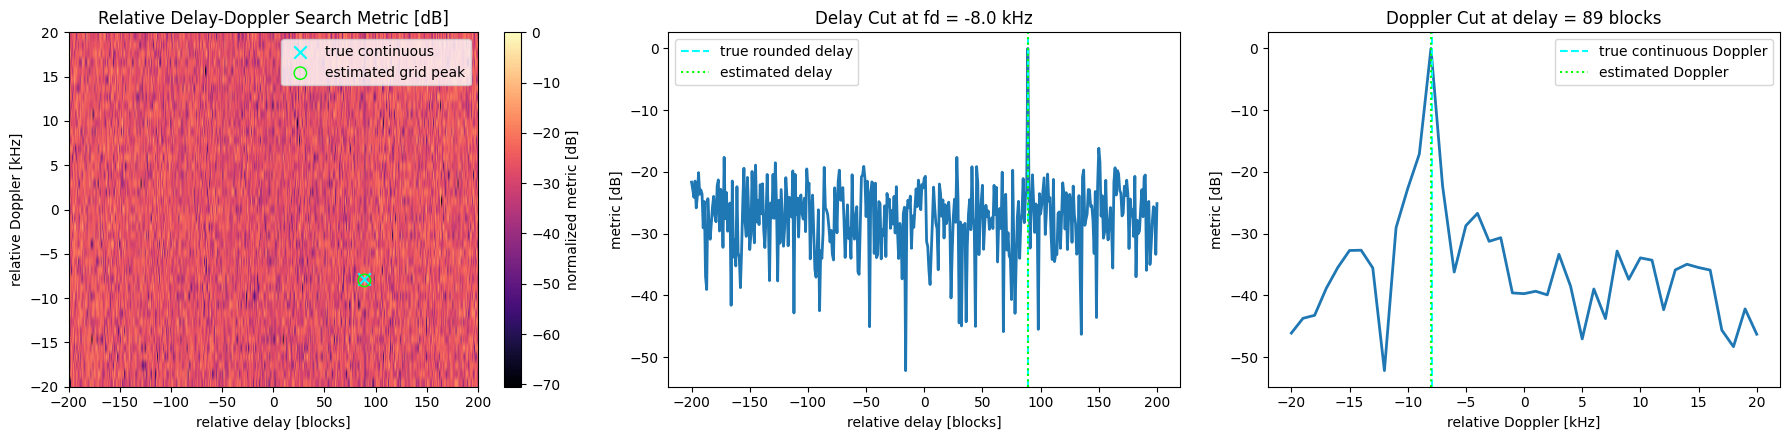

In [7]:
# --- Relative delay-Doppler estimation over the two received satellite signals ---
# Run the notebook from top to bottom. This cell reuses the global imports,
# constants, and search settings defined in the previous cells.

required_globals = [
    "c",
    "fc",
    "bandwidth",
    "Nfft",
    "Tfft",
    "delay_search_max_s",
    "doppler_search_max_hz",
    "doppler_grid_step_hz",
    "delay_grid_blocks",
    "doppler_grid_hz",
    "cir_sampling_frequency",
    "doppler_num_time_steps",
    "search_num_blocks",
    "collapse_channel",
]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise RuntimeError(f"Run the earlier setup cells first. Missing globals: {missing_globals}")


def _complex_hook(obj):
    if "__complex__" in obj:
        real, imag = obj["__complex__"]
        return complex(real, imag)
    return obj


def resolve_data_path(path="doppler_a_tx_tau_tx.jsonl"):
    candidate = Path(path)
    candidates = []
    if candidate.is_absolute():
        candidates.append(candidate)
    else:
        candidates.extend(
            [
                Path.cwd() / candidate,
                Path.cwd() / "Anti-jamming-unsync" / candidate,
                Path("Anti-jamming-unsync") / candidate,
                candidate,
            ]
        )

    for item in candidates:
        if item.exists():
            return item

    raise FileNotFoundError(
        f"Could not find {path}. Tried: {[str(p) for p in candidates]}"
    )


def load_last_doppler_entry(path="doppler_a_tx_tau_tx.jsonl"):
    resolved = resolve_data_path(path)
    with open(resolved, "r", encoding="utf-8") as f:
        lines = [line.strip() for line in f if line.strip()]
    if not lines:
        raise ValueError(f"{resolved} is empty.")
    return json.loads(lines[-1], object_hook=_complex_hook)


def resolve_delay_doppler_context(path="doppler_a_tx_tau_tx.jsonl"):
    required = ["a_tx", "tau_tx", "sat_positions", "sat_velocities"]
    if all(name in globals() for name in required):
        return {
            "a_tx": np.asarray(a_tx, dtype=complex),
            "a_eff": (np.asarray(a_eff, dtype=complex) if ("a_eff" in globals() and a_eff is not None) else None),
            "tau_tx": np.asarray(tau_tx, dtype=float),
            "sat_positions_enu_m": np.asarray(sat_positions, dtype=float),
            "sat_velocities_enu_mps": np.asarray(sat_velocities, dtype=float),
            "sat_names": list(names) if "names" in globals() else [f"sat{i}" for i in range(np.asarray(a_tx).shape[0])],
            "tx_position_enu_m": np.asarray(gnd_positions[0], dtype=float),
            "tx_velocity_enu_mps": np.asarray(tx_velocity_vec if "tx_velocity_vec" in globals() else np.zeros(3), dtype=float),
            "sampling_frequency_hz": float(globals().get("cir_sampling_frequency", np.nan)),
            "num_time_steps": int(np.asarray(a_tx).shape[-1]),
            "W_t": (np.asarray(W_t, dtype=complex) if ("W_t" in globals() and W_t is not None) else None),
            "precoder_mode": globals().get("precoder_mode", "off"),
            "use_precoding": bool(globals().get("a_eff", None) is not None),
        }

    entry = load_last_doppler_entry(path)
    return {
        "a_tx": np.asarray(entry["a_tx"], dtype=complex),
        "a_eff": (np.asarray(entry["a_eff"], dtype=complex) if entry.get("a_eff") is not None else None),
        "tau_tx": np.asarray(entry["tau_tx"], dtype=float),
        "sat_positions_enu_m": np.asarray(entry["sat_positions_enu_m"], dtype=float),
        "sat_velocities_enu_mps": np.asarray(entry["sat_velocities_enu_mps"], dtype=float),
        "sat_names": list(entry["sat_names"]),
        "tx_position_enu_m": np.asarray(entry["tx_position_enu_m"], dtype=float),
        "tx_velocity_enu_mps": np.asarray(entry["tx_velocity_enu_mps"], dtype=float),
        "sampling_frequency_hz": float(entry.get("sampling_frequency_hz", np.nan)),
        "num_time_steps": int(entry.get("num_time_steps", np.asarray(entry["a_tx"]).shape[-1])),
        "W_t": (np.asarray(entry["W_t"], dtype=complex) if entry.get("W_t") is not None else None),
        "precoder_mode": entry.get("precoder_mode", "off"),
        "use_precoding": bool(entry.get("use_precoding", False)),
    }


def los_doppler_hz(tx_pos, rx_pos, tx_vel, rx_vel, carrier_hz):
    los_vec = np.asarray(rx_pos, dtype=float) - np.asarray(tx_pos, dtype=float)
    los_norm = np.linalg.norm(los_vec)
    if los_norm < 1e-12:
        raise ValueError("TX and RX positions coincide, LOS Doppler is undefined.")
    los_hat = los_vec / los_norm
    v_rel = np.asarray(rx_vel, dtype=float) - np.asarray(tx_vel, dtype=float)
    radial_mps = np.dot(v_rel, los_hat)
    wavelength_m = c / carrier_hz
    return -radial_mps / wavelength_m


def build_satellite_link_table(ctx, carrier_hz, channel_key="a_tx"):
    a_signal_local = ctx.get(channel_key)
    if a_signal_local is None:
        raise ValueError(f"Requested channel_key={channel_key!r}, but it is not available in the context.")

    tau_tx_local = ctx["tau_tx"]
    n_rx = a_signal_local.shape[0]
    n_rx_ant = a_signal_local.shape[1]
    n_tx_ant = a_signal_local.shape[3]

    # collapse_channel(..., t_idx=None) returns
    # [num_rx*num_rx_ant, num_tx_ant, num_time_steps]
    H_t = collapse_channel(a_signal_local, t_idx=None)
    f_tx = np.ones(n_tx_ant, dtype=complex) / np.sqrt(n_tx_ant)

    links = []
    for rx_idx in range(n_rx):
        row0 = rx_idx * n_rx_ant
        row1 = (rx_idx + 1) * n_rx_ant
        Hk_t = H_t[row0:row1, :, :]

        hk_t = np.einsum("rts,t->rs", Hk_t, f_tx)
        w_rx = hk_t[:, 0]
        w_norm = np.linalg.norm(w_rx)
        if w_norm < 1e-18:
            w_rx = np.ones(n_rx_ant, dtype=complex) / np.sqrt(n_rx_ant)
        else:
            w_rx = w_rx / w_norm

        g_t = np.einsum("r,rs->s", np.conj(w_rx), hk_t)
        tau_eff_s = float(np.mean(np.asarray(tau_tx_local[rx_idx], dtype=float)))
        fd_geom_hz = los_doppler_hz(
            ctx["tx_position_enu_m"],
            ctx["sat_positions_enu_m"][rx_idx],
            ctx["tx_velocity_enu_mps"],
            ctx["sat_velocities_enu_mps"][rx_idx],
            carrier_hz,
        )

        links.append(
            {
                "rx_idx": rx_idx,
                "sat_name": ctx["sat_names"][rx_idx],
                "alpha_eff": g_t[0],
                "alpha_eff_mag": np.abs(g_t[0]),
                "tau_eff_s": tau_eff_s,
                "fd_geom_hz": fd_geom_hz,
                "g_t": g_t,
                "w_rx": w_rx,
                "f_tx": f_tx,
            }
        )

    return links


def qpsk_sequence(rng, length):
    constellation = np.array([1 + 1j, 1 - 1j, -1 + 1j, -1 - 1j], dtype=complex) / np.sqrt(2.0)
    return rng.choice(constellation, size=length)


def synthesize_from_common_pilot(
    tx_blocks,
    num_obs_blocks,
    left_pad,
    delay_blocks,
    fd_hz,
    alpha,
    t_block,
    snr_db,
    rng,
):
    blk = np.arange(num_obs_blocks)
    tx_idx = blk + left_pad - delay_blocks
    clean = alpha * tx_blocks[tx_idx] * np.exp(1j * 2.0 * np.pi * fd_hz * t_block * blk)
    signal_power = np.mean(np.abs(clean) ** 2)
    noise_power = signal_power / (10.0 ** (snr_db / 10.0))
    noise = np.sqrt(noise_power / 2.0) * (
        rng.standard_normal(num_obs_blocks) + 1j * rng.standard_normal(num_obs_blocks)
    )
    return clean + noise, clean, noise_power


def cross_delay_doppler_search(y_ref, y_other, delay_grid_blocks, doppler_grid_hz, t_block):
    n_other = np.arange(len(y_other))
    metric = np.zeros((len(doppler_grid_hz), len(delay_grid_blocks)), dtype=float)

    for d_idx, d_block in enumerate(delay_grid_blocks):
        ref_idx = n_other - d_block
        valid = (ref_idx >= 0) & (ref_idx < len(y_ref))
        if not np.any(valid):
            continue

        y2 = y_other[valid]
        y1 = y_ref[ref_idx[valid]]
        valid_n = n_other[valid]

        pair_product = y2 * np.conj(y1)
        phase_bank = np.exp(
            -1j * 2.0 * np.pi * doppler_grid_hz[:, None] * t_block * valid_n[None, :]
        )
        coherent_sum = phase_bank @ pair_product

        denom = np.sum(np.abs(y2) ** 2) * np.sum(np.abs(y1) ** 2) + 1e-12
        metric[:, d_idx] = (np.abs(coherent_sum) ** 2) / denom

    return metric


ctx = resolve_delay_doppler_context()
search_channel_key = "a_tx"  # options: "a_tx", "a_eff"
if search_channel_key not in {"a_tx", "a_eff"}:
    raise ValueError("search_channel_key must be 'a_tx' or 'a_eff'.")
if search_channel_key == "a_eff" and ctx.get("a_eff") is None:
    raise ValueError(
        "search_channel_key='a_eff' was requested, but no precoded CIR was found. "
        "Generate and save a_eff first."
    )

search_bw_hz = bandwidth
search_n_fft = Nfft
search_ts = 1.0 / search_bw_hz
search_t_fft = Tfft
delay_max_s = delay_search_max_s
fd_max_hz = doppler_search_max_hz
delta_fd_hz = doppler_grid_step_hz
expected_sampling_frequency_hz = cir_sampling_frequency
available_sionna_steps = int(ctx.get("num_time_steps", ctx["a_tx"].shape[-1]))
configured_sionna_time_step_us = 1e6 / expected_sampling_frequency_hz
configured_cir_observation_us = 1e6 * cir_observation_time_s
search_observation_us = 1e6 * search_num_blocks * search_t_fft

links = build_satellite_link_table(ctx, carrier_hz=fc, channel_key=search_channel_key)
if len(links) < 2:
    raise ValueError("This experiment expects at least two moving satellite receivers.")

search_param_table = pd.DataFrame(
    [
        {"parameter": "channel used", "value": search_channel_key},
        {"parameter": "precoder mode", "value": ctx.get("precoder_mode", "off")},
        {"parameter": "BW [MHz]", "value": search_bw_hz / 1e6},
        {"parameter": "N_fft", "value": search_n_fft},
        {"parameter": "T_s [ns]", "value": search_ts * 1e9},
        {"parameter": "T_fft [us]", "value": search_t_fft * 1e6},
        {"parameter": "D_max [ms]", "value": delay_max_s * 1e3},
        {"parameter": "f_d,max [kHz]", "value": fd_max_hz / 1e3},
        {"parameter": "delta f_d [kHz]", "value": delta_fd_hz / 1e3},
        {"parameter": "configured Sionna fs [Hz]", "value": expected_sampling_frequency_hz},
        {"parameter": "configured Sionna dt [us]", "value": configured_sionna_time_step_us},
        {"parameter": "configured CIR span [us]", "value": configured_cir_observation_us},
        {"parameter": "available Sionna time steps", "value": available_sionna_steps},
        {"parameter": "loaded Sionna fs [Hz]", "value": ctx.get("sampling_frequency_hz", np.nan)},
        {"parameter": "search observation [blocks]", "value": search_num_blocks},
        {"parameter": "search observation [us]", "value": search_observation_us},
        {"parameter": "n_delay", "value": len(delay_grid_blocks)},
        {"parameter": "n_doppler", "value": len(doppler_grid_hz)},
        {"parameter": "total hypotheses", "value": len(delay_grid_blocks) * len(doppler_grid_hz)},
        {
            "parameter": "phase rotation at fd,max [rad/block]",
            "value": 2.0 * np.pi * fd_max_hz * search_t_fft,
        },
        {
            "parameter": "cycles at fd,max [cycles/block]",
            "value": fd_max_hz * search_t_fft,
        },
    ]
)

link_table = pd.DataFrame(
    [
        {
            "sat_name": link["sat_name"],
            "tau_eff_ms": 1e3 * link["tau_eff_s"],
            "fd_geom_kHz": 1e-3 * link["fd_geom_hz"],
            "phase_per_block_rad": 2.0 * np.pi * link["fd_geom_hz"] * search_t_fft,
            "cycles_per_block": link["fd_geom_hz"] * search_t_fft,
            "abs_alpha_eff": link["alpha_eff_mag"],
        }
        for link in links[:2]
    ]
)

display(search_param_table)
display(link_table)

ref_idx = 0
other_idx = 1

delay_rel_blocks_float = (links[other_idx]["tau_eff_s"] - links[ref_idx]["tau_eff_s"]) / search_t_fft
delay_rel_blocks = int(np.rint(delay_rel_blocks_float))
delay_rel_residual_ns = (delay_rel_blocks_float - delay_rel_blocks) * search_t_fft * 1e9
fd_rel_hz_true = links[other_idx]["fd_geom_hz"] - links[ref_idx]["fd_geom_hz"]

nearest_delay_grid = int(delay_grid_blocks[np.argmin(np.abs(delay_grid_blocks - delay_rel_blocks))])
nearest_fd_grid_hz = float(doppler_grid_hz[np.argmin(np.abs(doppler_grid_hz - fd_rel_hz_true))])

if search_num_blocks <= np.max(np.abs(delay_grid_blocks)):
    raise ValueError(
        "search_num_blocks is too short for the chosen delay grid. Increase the "
        "observation length so that it exceeds the maximum searched delay."
    )

if np.abs(delay_rel_blocks) > np.max(np.abs(delay_grid_blocks)):
    print(
        f"WARNING: true relative delay {delay_rel_blocks} blocks is outside the search grid "
        f"[{delay_grid_blocks[0]}, {delay_grid_blocks[-1]}]."
    )

if np.abs(fd_rel_hz_true) > np.max(np.abs(doppler_grid_hz)):
    print(
        f"WARNING: true relative Doppler {fd_rel_hz_true/1e3:.2f} kHz is outside the search grid "
        f"[{doppler_grid_hz[0]/1e3:.1f}, {doppler_grid_hz[-1]/1e3:.1f}] kHz."
    )

if np.isfinite(ctx.get("sampling_frequency_hz", np.nan)) and not np.isclose(ctx["sampling_frequency_hz"], expected_sampling_frequency_hz):
    print(
        f"WARNING: loaded Sionna sampling_frequency_hz={ctx['sampling_frequency_hz']:.3f} does not match "
        f"the configured value {expected_sampling_frequency_hz:.3f}."
    )

num_obs_blocks = search_num_blocks
snr_db = 20.0
rng = np.random.default_rng(2026)

alpha_vec = np.array([links[ref_idx]["alpha_eff"], links[other_idx]["alpha_eff"]], dtype=complex)
alpha_vec = alpha_vec / (np.max(np.abs(alpha_vec)) + 1e-12)

delay_blocks_per_sat = np.array([0, delay_rel_blocks], dtype=int)
fd_per_sat_hz = np.array([links[ref_idx]["fd_geom_hz"], links[other_idx]["fd_geom_hz"]], dtype=float)

left_pad = int(max(np.max(delay_grid_blocks), np.max(delay_blocks_per_sat), 0) + 32)
right_pad = int(max(np.max(delay_grid_blocks), -np.min(delay_blocks_per_sat), 0) + 32)
tx_blocks = qpsk_sequence(rng, num_obs_blocks + left_pad + right_pad)

y_ref, y_ref_clean, noise_ref = synthesize_from_common_pilot(
    tx_blocks,
    num_obs_blocks,
    left_pad,
    delay_blocks_per_sat[0],
    fd_per_sat_hz[0],
    alpha_vec[0],
    search_t_fft,
    snr_db,
    rng,
)

y_other, y_other_clean, noise_other = synthesize_from_common_pilot(
    tx_blocks,
    num_obs_blocks,
    left_pad,
    delay_blocks_per_sat[1],
    fd_per_sat_hz[1],
    alpha_vec[1],
    search_t_fft,
    snr_db,
    rng,
)

metric = cross_delay_doppler_search(
    y_ref,
    y_other,
    delay_grid_blocks,
    doppler_grid_hz,
    search_t_fft,
)

peak_fd_idx, peak_delay_idx = np.unravel_index(np.argmax(metric), metric.shape)
delay_hat_blocks = int(delay_grid_blocks[peak_delay_idx])
fd_hat_hz = float(doppler_grid_hz[peak_fd_idx])

search_summary = pd.DataFrame(
    [
        {"quantity": "channel used", "value": search_channel_key},
        {"quantity": "precoder mode", "value": ctx.get("precoder_mode", "off")},
        {"quantity": "relative delay from geometry [blocks]", "value": delay_rel_blocks_float},
        {"quantity": "rounded block delay used in synthesis [blocks]", "value": delay_rel_blocks},
        {"quantity": "nearest delay grid [blocks]", "value": nearest_delay_grid},
        {"quantity": "sub-block residual [ns]", "value": delay_rel_residual_ns},
        {"quantity": "relative Doppler from geometry [kHz]", "value": fd_rel_hz_true / 1e3},
        {"quantity": "nearest Doppler grid [kHz]", "value": nearest_fd_grid_hz / 1e3},
        {"quantity": "estimated delay [blocks]", "value": delay_hat_blocks},
        {"quantity": "estimated Doppler [kHz]", "value": fd_hat_hz / 1e3},
        {"quantity": "delay error [blocks]", "value": delay_hat_blocks - delay_rel_blocks},
        {"quantity": "Doppler error to nearest grid [kHz]", "value": (fd_hat_hz - nearest_fd_grid_hz) / 1e3},
        {"quantity": "num observed blocks", "value": num_obs_blocks},
        {"quantity": "per-satellite block SNR [dB]", "value": snr_db},
    ]
)

display(search_summary)

metric_peak = max(np.max(metric), 1e-15)
metric_db = 10.0 * np.log10(metric / metric_peak + 1e-12)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

im = axes[0].imshow(
    metric_db,
    origin="lower",
    aspect="auto",
    extent=[delay_grid_blocks[0], delay_grid_blocks[-1], doppler_grid_hz[0] / 1e3, doppler_grid_hz[-1] / 1e3],
    cmap="magma",
)
axes[0].scatter(
    [delay_rel_blocks_float],
    [fd_rel_hz_true / 1e3],
    marker="x",
    s=80,
    c="cyan",
    label="true continuous",
)
axes[0].scatter(
    [delay_hat_blocks],
    [fd_hat_hz / 1e3],
    marker="o",
    s=80,
    facecolors="none",
    edgecolors="lime",
    label="estimated grid peak",
)
axes[0].set_title("Relative Delay-Doppler Search Metric [dB]")
axes[0].set_xlabel("relative delay [blocks]")
axes[0].set_ylabel("relative Doppler [kHz]")
axes[0].legend(loc="upper right")
fig.colorbar(im, ax=axes[0], label="normalized metric [dB]")

axes[1].plot(delay_grid_blocks, metric_db[peak_fd_idx, :], lw=2)
axes[1].axvline(delay_rel_blocks, color="cyan", ls="--", label="true rounded delay")
axes[1].axvline(delay_hat_blocks, color="lime", ls=":", label="estimated delay")
axes[1].set_title(f"Delay Cut at fd = {fd_hat_hz/1e3:.1f} kHz")
axes[1].set_xlabel("relative delay [blocks]")
axes[1].set_ylabel("metric [dB]")
axes[1].legend(loc="best")

axes[2].plot(doppler_grid_hz / 1e3, metric_db[:, peak_delay_idx], lw=2)
axes[2].axvline(fd_rel_hz_true / 1e3, color="cyan", ls="--", label="true continuous Doppler")
axes[2].axvline(fd_hat_hz / 1e3, color="lime", ls=":", label="estimated Doppler")
axes[2].set_title(f"Doppler Cut at delay = {delay_hat_blocks} blocks")
axes[2].set_xlabel("relative Doppler [kHz]")
axes[2].set_ylabel("metric [dB]")
axes[2].legend(loc="best")

plt.tight_layout()

print("Search completed over two received signals (satellite 0 as reference, satellite 1 as target).")
print(f"Channel used: {search_channel_key} (precoder_mode={ctx.get('precoder_mode', 'off')})")
print(f"Delay grid: {delay_grid_blocks[0]} ... {delay_grid_blocks[-1]} blocks ({len(delay_grid_blocks)} hypotheses)")
print(f"Doppler grid: {doppler_grid_hz[0]/1e3:.1f} ... {doppler_grid_hz[-1]/1e3:.1f} kHz ({len(doppler_grid_hz)} hypotheses)")
print(f"Total hypotheses: {metric.size}")
